<a href="https://colab.research.google.com/github/Lthao-stack/tu-van-om-sot-tre-em-/blob/main/okeroi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving kiến thức ốm sốt ở trẻ em.zip to kiến thức ốm sốt ở trẻ em.zip
Archive:  kiến thức ốm sốt ở trẻ em.zip
  inflating: Symptom2Disease.csv     
CSV tìm thấy: ['Symptom2Disease.csv', 'sample_data/mnist_train_small.csv', 'sample_data/california_housing_test.csv', 'sample_data/mnist_test.csv', 'sample_data/california_housing_train.csv']
Đã đọc: Symptom2Disease.csv
Sau làm sạch: (1153, 2)
Accuracy: 0.9523809523809523
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         9
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       0.91      1.00      0.95        10
                         Dengue       0.89      0.80      0.84     

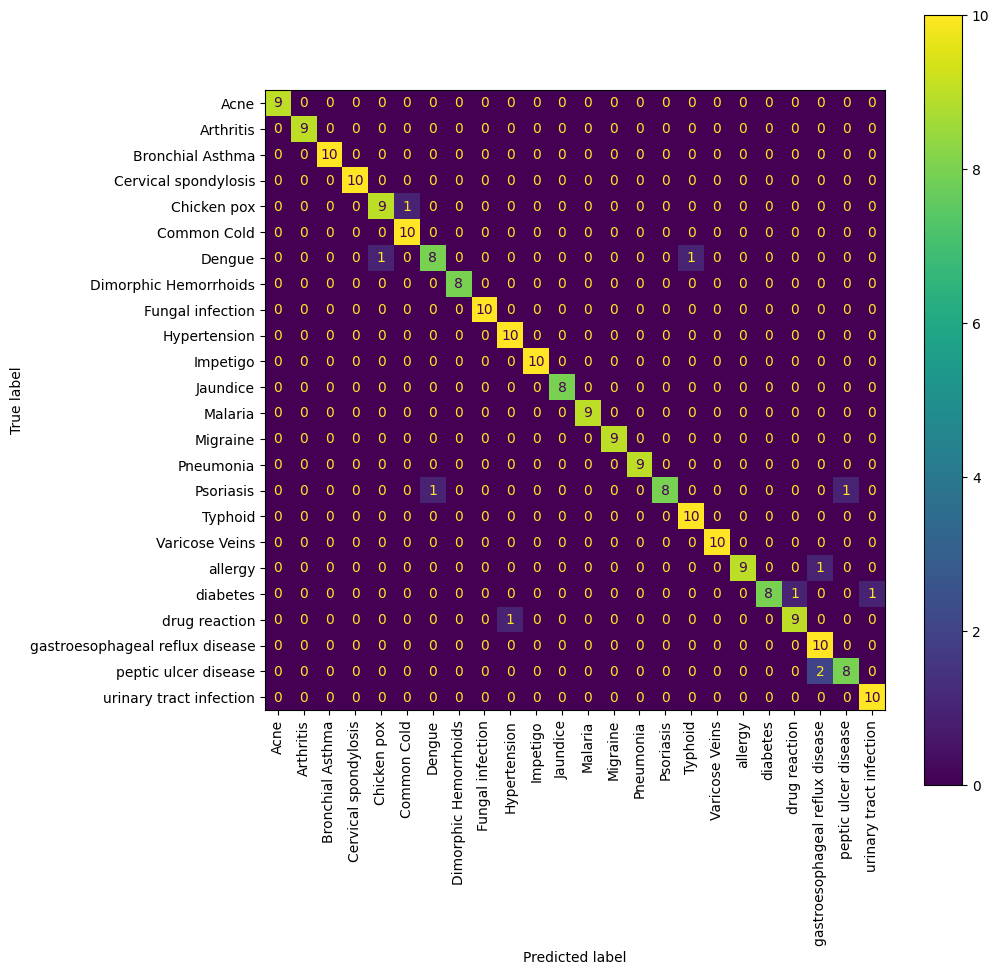

/tmp/ipykernel_33958/3912353750.py:799: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_33958/3912353750.py:799: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_33958/3912353750.py:866: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot_ui = gr.Chatbot(
/tmp/ipykernel_33958/3912353750.py:866: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=F

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f65a18374ea3c981a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:

!pip install gradio scikit-learn pandas matplotlib -q

import pandas as pd
import gradio as gr
import re
import glob
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ===================== UPLOAD DATASET =====================

uploaded = files.upload()

for zip_file in uploaded.keys():
    !unzip -o "{zip_file}"

csv_files = glob.glob("**/*.csv", recursive=True)
print("CSV tìm thấy:", csv_files)

all_df = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(file)

        if "text" in temp_df.columns and "label" in temp_df.columns:
            all_df.append(temp_df[["text", "label"]])
            print("Đã đọc:", file)

    except Exception as e:
        print("Lỗi:", file, e)

if len(all_df) == 0:
    raise ValueError("Không có dataset hợp lệ. Dataset cần có cột text và label.")

df = pd.concat(all_df, ignore_index=True)

# ===================== LÀM SẠCH DATASET =====================

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

df = df.dropna(subset=["text", "label"])

df = df[
    (df["text"] != "") &
    (df["text"].str.lower() != "nan") &
    (df["label"] != "") &
    (df["label"].str.lower() != "nan")
]

df = df.drop_duplicates()

print("Sau làm sạch:", df.shape)

# ===================== TRAIN MODEL =====================

X = df["text"]
y = df["label"]

label_counts = y.value_counts()

can_stratify = (
    len(label_counts) >= 2 and
    label_counts.min() >= 2
)

if can_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words=None,
            ngram_range=(1, 2)
        )
    ),
    (
        "clf",
        LogisticRegression(max_iter=3000)
    )
])

model.fit(X_train, y_train)

pred_test = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_test))

print(
    classification_report(
        y_test,
        pred_test,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, pred_test)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=90, ax=ax)

plt.show()

# ===================== MEMORY =====================

def new_state():
    return {"history": [], "asked_missing": set()}

state = new_state()

# ===================== KEYWORDS =====================

GREETINGS = [
    "hi", "hello", "alo",
    "chào", "xin chào",
    "chào bot", "bot ơi",
    "chào bác sĩ"
]

END_WORDS = [
    "cảm ơn",
    "bye",
    "tạm biệt",
    "ổn rồi",
    "xong rồi",
    "được rồi",
    "ok rồi",
    "oke rồi"
]

DOMAIN_WORDS = [
    "bé", "trẻ", "con", "cháu",
    "sốt", "ho", "sổ mũi",
    "nghẹt mũi", "đau họng",
    "khó thở", "nôn", "ói",
    "tiêu chảy", "đi ngoài",
    "đau bụng", "phát ban",
    "mụn", "ngứa",
    "mẩn", "co giật",
    "đau tai", "đỏ mắt",
    "chảy máu cam",
    "tiểu buốt",
    "tiểu rắt",
    "ốm", "cảm",
    "mụn nước",
    "nổi mụn"
]

danger_words = [
    "co giật",
    "khó thở",
    "tím tái",
    "tím môi",
    "lừ đừ",
    "li bì",
    "khó đánh thức",
    "không uống được",
    "nôn liên tục",
    "thở yếu",
    "ngưng thở",
    "tay chân lạnh",
    "chấm xuất huyết",
    "rút lõm ngực"
]

symptom_keywords = [
    "sốt", "sốt nhẹ", "sốt cao",
    "nóng", "nóng người", "hâm hấp",
    "âm ấm", "ớn lạnh",

    "ho", "ho khan", "ho đờm",
    "sổ mũi", "chảy nước mũi",
    "nghẹt mũi", "khụt khịt",
    "hắt hơi",
    "khó thở", "thở nhanh",
    "thở mệt", "thở gấp",
    "thở rít", "khò khè",
    "đau họng", "rát họng",
    "khàn tiếng", "đau ngực",
    "rút lõm ngực",

    "nôn", "ói", "buồn nôn",
    "tiêu chảy", "đi ngoài",
    "phân lỏng", "đau bụng",

    "biếng ăn",
    "không ăn",
    "bú kém",
    "bỏ bú",
    "uống kém",
    "không uống được",

    "co giật",
    "lừ đừ",
    "li bì",
    "mệt",
    "mệt mỏi",
    "ngủ nhiều",
    "khó đánh thức",
    "quấy khóc",
    "đau đầu",

    "phát ban",
    "nổi ban",
    "nổi mụn",
    "mụn nước",
    "mẩn đỏ",
    "mẩn ngứa",
    "ngứa",
    "ngứa da",
    "nổi đỏ",
    "nổi mề đay",
    "dị ứng",
    "nổi chấm đỏ",
    "chấm xuất huyết",
    "bầm tím",

    "đau tai",
    "chảy mủ tai",
    "đỏ mắt",
    "ghèn mắt",
    "mụn miệng",
    "loét miệng",
    "nhiệt miệng",

    "tiểu buốt",
    "tiểu rắt",
    "tiểu ít",

    "nổi ở tay",
    "nổi ở chân",
    "loét lưỡi",

    "chảy máu cam",
    "tay chân lạnh",

    "sưng môi",
    "sưng mắt",

    "ốm",
    "cảm",
    "cảm cúm",
    "cảm lạnh",
    "mọc răng",
    "khó chịu",
    "không khỏe"
]

# ===================== NLP =====================

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zà-ỹ0-9\s.,]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def extract_temperature(text):
    text = text.lower().replace(",", ".")

    matches = re.findall(
        r"\b(3[5-9]|4[0-2])(?:\.(\d))?\b",
        text
    )

    if matches:
        main, dec = matches[-1]
        return float(main + "." + dec) if dec else float(main)

    return None


def extract_age(text):
    text = text.lower()

    patterns = [
        r"\b\d+\s*tuổi\b",
        r"\b\d+\s*tháng\s*tuổi\b",
        r"\bbé\s*\d+\s*tháng\b",
        r"\bcon\s*\d+\s*tuổi\b",
        r"\bcháu\s*\d+\s*tuổi\b",
        r"\bsơ\s*sinh\b"
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)

    return None


def has_symptom(text):
    text = text.lower()
    return any(w in text for w in symptom_keywords)


def has_fever_info(text):
    text = text.lower()

    yes_fever_words = [
        "sốt",
        "bị sốt",
        "sốt cao",
        "sốt nhẹ",
        "nóng",
        "nóng người",
        "hâm hấp",
        "âm ấm"
    ]

    no_fever_words = [
        "không",
        "không sốt",
        "không bị sốt",
        "không ốm sốt",
        "không sốt ốm",
        "không nóng",
        "không nóng người",
        "không hâm hấp",
        "chưa sốt",
        "không có sốt"
    ]

    has_yes = any(w in text for w in yes_fever_words)
    has_no = any(w in text for w in no_fever_words)

    return has_yes or has_no


def has_no_fever(text):
    text = text.lower()

    no_fever_words = [
        "không",
        "không sốt",
        "không bị sốt",
        "không ốm sốt",
        "không sốt ốm",
        "không nóng",
        "không nóng người",
        "không hâm hấp",
        "chưa sốt",
        "không có sốt"
    ]

    return any(w in text for w in no_fever_words)


def has_enough_information(text):
    text = normalize_text(text)

    age = extract_age(text)
    temp = extract_temperature(text)
    symptom_found = has_symptom(text)

    fever_known = has_fever_info(text)

    missing = []

    if not age:
        missing.append("tuổi của bé")

    if not temp and not fever_known:
        missing.append("nhiệt độ hoặc bé có sốt hay không")

    if not symptom_found:
        missing.append("triệu chứng hiện tại")

    return len(missing) == 0, missing


def is_greeting(text):
    return text.lower().strip() in GREETINGS


def is_end(text):
    return any(w in text.lower() for w in END_WORDS)


def is_medical_domain(text):
    return any(w in text.lower() for w in DOMAIN_WORDS)


def has_any(text, words):
    return any(w in text for w in words)

# ===================== RESPONSE CƠ BẢN =====================

def greeting_response():
    return """
Xin chào! 👋

Mình là hệ thống tư vấn thông minh hỗ trợ theo dõi và xử trí sốt ở trẻ em sử dụng Generative AI.
"""


def out_domain_response():
    return """
Xin lỗi, nội dung này không đúng chuyên môn của hệ thống.

Hệ thống chỉ hỗ trợ tư vấn theo dõi và xử trí sốt ở trẻ em.
"""

# ===================== RISK =====================

def evaluate_risk(text):
    text = text.lower()
    temp = extract_temperature(text)

    if any(w in text for w in danger_words):
        return "🔴 NGUY HIỂM CAO"

    if temp and temp >= 39.5:
        return "🟠 CẦN THEO DÕI SÁT"

    if temp and temp >= 37.5:
        return "🟡 NHẸ - TRUNG BÌNH"

    return "🟢 CHƯA GHI NHẬN NGUY HIỂM"


def fever_level(temp):
    if temp is None:
        return "Không sốt hoặc chưa rõ"

    if temp < 37.5:
        return "Chưa phải sốt rõ"

    if temp < 38.5:
        return "Sốt nhẹ"

    if temp < 39.5:
        return "Sốt mức vừa"

    return "Sốt cao"


def risk_html(risk):
    if "🔴" in risk:
        color = "#ef4444"
    elif "🟠" in risk:
        color = "#f97316"
    elif "🟡" in risk:
        color = "#eab308"
    elif "⚪" in risk:
        color = "#64748b"
    else:
        color = "#22c55e"

    return f"""
<div style="
padding:12px;
border-radius:12px;
background:{color};
color:white;
font-weight:bold;
text-align:center;">
{risk}
</div>
"""

# ===================== CHẨN ĐOÁN =====================

def diagnose_disease(context, temp):
    t = context.lower()

    if has_any(t, ["co giật", "li bì", "lừ đừ", "khó đánh thức", "tím môi", "tím tái"]):
        return "Tình trạng nguy hiểm"

    if has_any(t, ["chấm xuất huyết", "chảy máu cam", "bầm tím", "tay chân lạnh"]):
        return "Sốt xuất huyết"

    if has_any(t, ["thở nhanh", "thở mệt", "rút lõm ngực"]):
        return "Viêm phổi"

    if has_any(t, ["khò khè"]) and has_any(t, ["khó thở", "ho"]):
        return "Hen phế quản"

    if has_any(t, ["loét miệng", "mụn miệng", "nổi ở tay", "nổi ở chân", "loét lưỡi"]):
        return "Tay chân miệng"

    if has_any(t, ["mụn nước"]) and has_any(t, ["ngứa", "sốt"]):
        return "Thủy đậu"

    if has_any(t, ["mẩn ngứa", "nổi mề đay", "sưng môi", "sưng mắt"]):
        return "Dị ứng"

    if has_any(t, ["tiểu buốt", "tiểu rắt", "tiểu đục", "tiểu ít"]):
        return "Nhiễm trùng tiểu"

    if has_any(t, ["nôn", "ói", "tiêu chảy", "đi ngoài", "đau bụng", "phân lỏng"]):
        return "Viêm dạ dày ruột"

    if has_any(t, ["đau tai", "chảy mủ tai"]):
        return "Viêm tai giữa"

    if has_any(t, ["đỏ mắt", "ghèn mắt"]):
        return "Viêm kết mạc"

    if has_any(t, ["đau họng", "rát họng", "khàn tiếng"]):
        return "Viêm họng"

    if has_any(t, ["ho", "sổ mũi", "nghẹt mũi", "chảy nước mũi", "khụt khịt", "hắt hơi"]):
        return "Cảm lạnh"

    if has_any(t, ["mụn nước"]):
        return "Thủy đậu"

    if has_any(t, ["phát ban", "mẩn đỏ", "ngứa da", "nổi đỏ", "nổi mụn"]):
        return "Viêm da"

    if temp and temp >= 38.5:
        return "Sốt virus"

    return "Chưa xác định rõ"

# ===================== XỬ TRÍ THEO ĐÚNG BỆNH =====================

def generate_advice(disease_name, temp, risk):

    if risk == "🔴 NGUY HIỂM CAO":
        return [
            "- Đưa bé đến cơ sở y tế sớm để được kiểm tra.",
            "- Không tự ý dùng thuốc khi bé có dấu hiệu nguy hiểm.",
            "- Theo dõi nhịp thở, ý thức và tình trạng uống nước của bé."
        ]

    advice_map = {
        "Cảm lạnh": [
            "- Nhỏ nước muối sinh lý 0.9% khi bé sổ mũi hoặc nghẹt mũi.",
            "- Cho bé uống nước ấm và nghỉ ngơi.",
            "- Giữ ấm vừa phải, tránh gió lạnh.",
            "- Theo dõi nhiệt độ và tình trạng ho, sổ mũi của bé."
        ],

        "Viêm họng": [
            "- Cho bé uống nước ấm.",
            "- Cho ăn thức ăn mềm, dễ nuốt.",
            "- Có thể súc miệng bằng nước muối sinh lý nếu bé đủ lớn.",
            "- Nên đi khám nếu đau họng nhiều, sốt kéo dài hoặc bỏ ăn."
        ],

        "Viêm phổi": [
            "- Cho bé nghỉ nơi thoáng khí.",
            "- Theo dõi nhịp thở và mức độ khó thở.",
            "- Đưa bé đi khám nếu ho nhiều, thở nhanh, thở mệt hoặc mệt hơn.",
            "- Không tự ý dùng kháng sinh khi chưa có chỉ định."
        ],

        "Sốt xuất huyết": [
            "- Cho bé uống nhiều nước.",
            "- Theo dõi chảy máu cam, chấm xuất huyết, đau bụng hoặc tay chân lạnh.",
            "- Không dùng Ibuprofen hoặc Aspirin.",
            "- Nên đưa bé đi khám để xét nghiệm và theo dõi."
        ],

        "Tay chân miệng": [
            "- Cho bé ăn mềm, nguội, dễ nuốt.",
            "- Giữ vệ sinh tay và đồ dùng của bé.",
            "- Theo dõi sốt cao, giật mình, run tay chân hoặc lừ đừ.",
            "- Nên đi khám nếu bé bỏ ăn, bỏ uống hoặc mệt nhiều."
        ],

        "Thủy đậu": [
            "- Giữ da sạch và khô.",
            "- Tránh để bé gãi làm vỡ mụn nước.",
            "- Cho bé mặc quần áo rộng, thoáng.",
            "- Theo dõi sốt, nhiễm trùng da hoặc mụn lan nhiều."
        ],

        "Dị ứng": [
            "- Tránh tác nhân nghi gây dị ứng.",
            "- Giữ da sạch, tránh gãi.",
            "- Theo dõi sưng môi, sưng mắt hoặc khó thở.",
            "- Nên đi khám nếu nổi mẩn lan nhanh hoặc ngứa nhiều."
        ],

        "Nhiễm trùng tiểu": [
            "- Cho bé uống đủ nước.",
            "- Theo dõi tiểu buốt, tiểu rắt, tiểu ít hoặc nước tiểu đục.",
            "- Nên đưa bé đi khám để kiểm tra nước tiểu.",
            "- Không tự ý dùng kháng sinh."
        ],

        "Viêm dạ dày ruột": [
            "- Bù nước bằng oresol pha đúng hướng dẫn.",
            "- Cho bé ăn mềm, dễ tiêu.",
            "- Theo dõi số lần đi ngoài, nôn ói và dấu hiệu mất nước.",
            "- Nên đi khám nếu bé nôn nhiều, tiêu chảy nhiều hoặc tiểu ít."
        ],

        "Viêm tai giữa": [
            "- Giữ tai bé khô sạch.",
            "- Không tự ý nhỏ thuốc vào tai nếu chưa có chỉ định.",
            "- Nên đưa bé đi khám nếu đau tai hoặc chảy mủ tai.",
            "- Theo dõi sốt và mức độ quấy khóc."
        ],

        "Viêm kết mạc": [
            "- Lau mắt bằng gạc sạch và nước muối sinh lý.",
            "- Không để bé dụi mắt.",
            "- Rửa tay thường xuyên để tránh lây lan.",
            "- Nên đi khám nếu mắt sưng đau, nhiều ghèn hoặc nhìn kém."
        ],

        "Viêm da": [
            "- Giữ vùng da sạch và khô.",
            "- Tránh để bé gãi vùng da bị ngứa.",
            "- Theo dõi lan rộng, sưng đỏ hoặc chảy dịch.",
            "- Nên đi khám nếu tổn thương da lan nhanh hoặc có mủ."
        ],

        "Sốt virus": [
            "- Cho bé nghỉ ngơi.",
            "- Cho bé uống đủ nước.",
            "- Theo dõi nhiệt độ đều đặn.",
            "- Có thể dùng Paracetamol 10–15mg/kg/lần khi sốt từ 38.5°C trở lên."
        ],

        "Hen phế quản": [
            "- Cho bé ngồi đầu cao.",
            "- Tránh khói bụi, lông thú, mùi kích thích.",
            "- Theo dõi tiếng khò khè và mức độ khó thở.",
            "- Nên đưa bé đi khám nếu khò khè hoặc khó thở tăng."
        ],

        "Tình trạng nguy hiểm": [
            "- Đưa bé đến cơ sở y tế sớm.",
            "- Theo dõi ý thức, nhịp thở và màu sắc môi da.",
            "- Không tự ý điều trị tại nhà khi bé có dấu hiệu nguy hiểm."
        ],

        "Chưa xác định rõ": [
            "- Theo dõi thêm triệu chứng của bé.",
            "- Cho bé nghỉ ngơi và uống đủ nước.",
            "- Nếu triệu chứng tăng lên hoặc kéo dài, nên đưa bé đi khám."
        ]
    }

    return advice_map.get(
        disease_name,
        [
            "- Theo dõi thêm tình trạng của bé.",
            "- Cho bé nghỉ ngơi và uống đủ nước.",
            "- Nếu có dấu hiệu bất thường, nên đưa bé đi khám."
        ]
    )

# ===================== GENERATE RESPONSE =====================

def generate_response(user_input):

    global state

    state["history"].append(user_input)

    context = " ".join(state["history"])

    enough, missing = has_enough_information(context)

    if not enough:
        asked_missing = state.setdefault("asked_missing", set())
        missing_to_ask = [m for m in missing if m not in asked_missing]

        if not missing_to_ask:
            if "nhiệt độ hoặc bé có sốt hay không" in missing:
                missing_to_ask = ["nhiệt độ hoặc bé có sốt hay không"]
            elif "tuổi của bé" in missing:
                missing_to_ask = ["tuổi của bé"]
            else:
                missing_to_ask = [missing[0]]

        asked_missing.update(missing)

        return f"""
Bạn có thể cho tôi biết thêm {", ".join(missing_to_ask)} không?
"""

    state["asked_missing"] = set()

    risk = evaluate_risk(context)
    temp = extract_temperature(context)
    age = extract_age(context)
    disease_name = diagnose_disease(context, temp)
    advice = generate_advice(disease_name, temp, risk)

    fever_status = "Không" if has_no_fever(context) and temp is None else "Có"

    return f"""
NHẬN ĐỊNH

- Tuổi: {age if age else "Chưa rõ"}
- Bé có sốt: {fever_status}
- Nhiệt độ: {temp if temp else "Chưa rõ"} ({fever_level(temp)})
- Chẩn đoán hiện tại: {disease_name}

XỬ TRÍ

{chr(10).join(advice)}

LƯU Ý

Thông tin chỉ mang tính tham khảo.
"""

# ===================== CHATBOT =====================

def chatbot(user_input, history):

    global state

    text = user_input.strip()

    if not text:
        return (
            "",
            history,
            risk_html("🟢 CHƯA ĐÁNH GIÁ"),
            "Hệ thống sẽ đánh giá khi có thông tin."
        )

    if is_greeting(text):
        return (
            "",
            history + [(text, greeting_response())],
            risk_html("🟢 CHƯA ĐÁNH GIÁ"),
            "Đang chờ thông tin."
        )

    if is_end(text):
        state = new_state()

        return (
            "",
            history + [
                (
                    text,
                    "Cuộc tư vấn đã kết thúc. Nếu bạn hỏi tiếp hệ thống sẽ hiểu là ca mới."
                )
            ],
            risk_html("🟢 CHƯA ĐÁNH GIÁ"),
            "Đã reset phiên tư vấn."
        )

    if len(state["history"]) == 0 and not is_medical_domain(text):
        return (
            "",
            history + [(text, out_domain_response())],
            risk_html("⚪ NGOÀI CHUYÊN MÔN"),
            "Ngoài phạm vi tư vấn."
        )

    answer = generate_response(text)

    risk = evaluate_risk(
        " ".join(state["history"])
    )

    return (
        "",
        history + [(text, answer)],
        risk_html(risk),
        risk
    )


def reset_chat():

    global state

    state = new_state()

    return (
        [],
        risk_html("🟢 CHƯA ĐÁNH GIÁ"),
        "Hệ thống sẽ đánh giá khi có thông tin."
    )

# ===================== UI =====================

with gr.Blocks(

    theme=gr.themes.Soft(),

    css="""
    .gradio-container{
        background: radial-gradient(circle at top, #1e293b 0%, #0f172a 45%, #020617 100%)!important;
        color:#e2e8f0!important;
    }

    #title{
        text-align:center;
        color:#7dd3fc;
        margin-bottom:10px;
        text-shadow:0 2px 12px rgba(56,189,248,.35);
    }

    .sidebar{
        background:linear-gradient(180deg,#111827 0%,#0b1220 100%);
        padding:16px;
        border-radius:16px;
        border:1px solid #334155;
        box-shadow:0 10px 24px rgba(2,6,23,.35);
    }

    .sidebar h3{
        color:#93c5fd!important;
        margin-top:2px!important;
    }

    #chatbot-card{
        background:rgba(15,23,42,.72);
        border:1px solid #334155;
        border-radius:16px;
        padding:10px;
        box-shadow:0 10px 24px rgba(2,6,23,.35);
    }

    textarea{
        background:#1e293b!important;
        color:#f8fafc!important;
        border:1px solid #475569!important;
        border-radius:10px!important;
    }

    button{
        font-weight:700!important;
        border-radius:10px!important;
    }

    #send-btn{
        background:#0284c7!important;
        color:white!important;
        border:none!important;
    }

    #clear-btn{
        background:#334155!important;
        color:#e2e8f0!important;
        border:1px solid #64748b!important;
    }
    """
) as demo:

    gr.Markdown("""
    <h2 id="title">
    Hệ thống tư vấn thông minh về theo dõi
    và xử trí sốt ở trẻ em sử dụng Generative AI
    </h2>
    """)

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown("""
            <div class="sidebar">

            ### Mức độ nguy hiểm

            - 🟢 Bình thường
            - 🟡 Nhẹ - trung bình
            - 🟠 Cần theo dõi sát
            - 🔴 Nguy hiểm cao

            </div>
            """)

            risk_level = gr.HTML(
                risk_html("🟢 CHƯA ĐÁNH GIÁ")
            )

            risk_note = gr.Markdown(
                "Hệ thống sẽ đánh giá khi có thông tin."
            )

        with gr.Column(scale=4):

            with gr.Group(elem_id="chatbot-card"):
                chatbot_ui = gr.Chatbot(
                    value=[],
                    height=500,
                    bubble_full_width=False
                )

            msg = gr.Textbox(
                label="Câu hỏi của bạn",
                placeholder="Nhập tình trạng của bé..."
            )

            with gr.Row():

                send = gr.Button("Gửi", elem_id="send-btn")

                clear = gr.Button("Ca mới", elem_id="clear-btn")

    send.click(
        chatbot,
        [msg, chatbot_ui],
        [msg, chatbot_ui, risk_level, risk_note]
    )

    msg.submit(
        chatbot,
        [msg, chatbot_ui],
        [msg, chatbot_ui, risk_level, risk_note]
    )

    clear.click(
        reset_chat,
        None,
        [chatbot_ui, risk_level, risk_note]
    )

demo.launch()